# Numpy Demonstration
This notebook is accompanied with a lecture video for "Python for Data Science"

Numpy (Numerical Python) package is `The fundamental package for scientific computing with Python` as stated in https://numpy.org/

Numpy is a massive package and we can just scratch its surface during this course. However, this notebook is to demonstrate a bit how Numpy provides an efficient way for doing various calculations elegantly. The things that may take several lines of code in Java programming language, for example, can often be done with just one short line of code in Python using Numpy. You will see soon what I mean.

Numpy also provides many ready made functions for us. In science, we are frequently interrested in the distributions associated with different phenomenan. For example, rolling a six sided dice should follow uniform distribution such that each different outcome has equal probability to occur. Hence, dice eye count 1 should occur with probability 1/6 and it should be so also for rest of the eye counts. As there are just countable number of different values the dice rolling event can take (hence values 1, 2, 3, 4, 5 and 6), the probability distribution we just discussed in called `Discrete`.

Let's take another example. I draw a line on the ground which is 6 meters long. So, it has starting and ending points. I then ask you to place a marker between those start and end points. Then we measure how far the marker is from the start position. It is equally likely for you to put that marker in any of the positions between start and end positions, don't you think? Basically we could then measure for example that the marker is 3.45**43** meters away from the start or, for example, that the marker is 3.45**34** meter away from the start. Hence, all the values between 0 and 6 would be possible - hence not just integers but all the decimal values. In this case we are dealing with `continuous` distribution.

Let's demonstrate these examples with Numpy as they give us a reason to play with couple of Numpy functions already and we learn the basics of doing statistical simulations also :)




In [1]:
#%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import collections


## Example 1: Rolling dice simulation
Remember what was discussed at the beginning of this notebook

In [2]:
# Let's first generate some dice rolls based on discrete uniform distribution
dice_eye_counts = np.random.randint(0,6,10000000)+1   # Notice, the end limit is exclusive! 
#dice_eye_counts[:10] # just showing the first 10 - if there are even that many

In [3]:
# Counting the number of times different eye counts occured in our simulated sample
distribution = collections.Counter(dice_eye_counts)
distribution

Counter({3: 1668070,
         1: 1664957,
         6: 1665690,
         5: 1665714,
         4: 1667003,
         2: 1668566})

### Drawing the Bar chart for our data. 

Note, that although the eye counts are marked as 1, 2,..., 6 - they `could` have been also something else,
like A,B,C,D,E,F or colored sides of the dice, for example, White, Red, Blue, Green, Black and Yellow. Hence, we might not treat 
those eye counts as number but as categories. 

Don't get confused! It is good to note that in some context you might threat those values really as numbers, sometimes as categories. Now we assume that they are just
categories - for example, maybe we had just a colored dice without eye counts and we have decoded our results like 1=White, 2=Red, 3=Blue, 4=Green, 5=Black, 6=Yellow.

So, in this case we have actually just coded our results as 1,2,...,6 but actually they are just different categories.

And because they are not numbers here,we utilize `bar chart` now instead of `histogram`. Histogram often looks much like bar chart but there on the x-axis we really have numerical scale. Now you need to understand that the values on a bar chart are just the categories. To emphasize that, there is space (air) between the bars for the categories. We will be talking about histogram bit later. 

<BarContainer object of 6 artists>

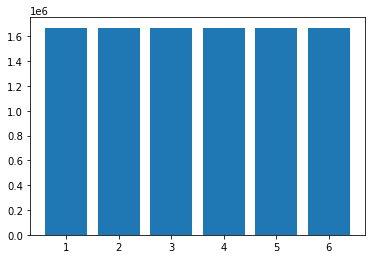

In [4]:
# The bar function needs the labels for the categories and the corresponding counts. We have
# have them in dictionary form already, we need to just use its the keys() and values() functions

plt.bar(distribution.keys(), distribution.values())

### Play with the previous steps next 
Note! This is discussed on the lecture video

## Example 2: Placing marker on the line
remember what was discussed at the beginning of this notebook

In [5]:
distances = np.random.uniform(0,6,100000000)
distances[:10] # Showing the first 10 randomly generated values

array([1.87324052, 1.52065475, 0.38859791, 0.69282931, 5.25551633,
       3.55160532, 1.70941185, 2.42951309, 1.67095641, 3.15779302])

Now the thing is that there is no point in counting directly the amount of same values in that *distances* array. This is because there most likely are not even 2 exactly same values in that numpy array (ndarray). So what to do next?

Better idea would be to first divide the interval from 0 to 6 into N equally spaced intervals. Then checking which values of *distances* array fall into which interval and then make a visualization pretty much like the bar chart above to illustrate the counts of values falling into those intervals. But notice that now we would need to have our x axis telling us that the values on the x axis are really numerical values.

Why did I write that 'Better idea **would** be ... Well, Numpy's hist method can already do that for us, and actually much more...

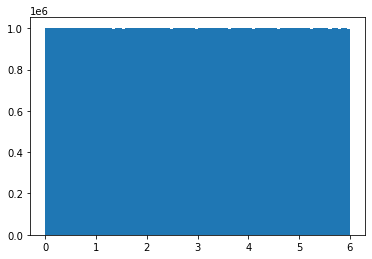

In [6]:
#plt.hist(distances);  # by default hist uses 10 bins, hence divides the full interval into 10 sub intervals
plt.hist(distances, bins=100);  # With the bins option we can control the number of bins as we wish, but that you be in relation with original data

By the way, note that there is no emply space between bars - unless there are no observations related to that subinterval. This is one of the difference between bar charts and histograms.

### Play with the previous steps next 
Note! This is discussed on the lecture video

## Example 3: Calculating BMI 

Ok, to demonstrate how Numpy can help us with various calculations, we consider an example of calculating the BMI (Body Mass Index) for Finnish males.

The formula for calculating the BMI is 

$$  BMI = \frac {weight}{height^2},$$

where the weight is given in kilos and the height is given in meters.

It is known that the male heights follows `normal distribution` which is also known as `Gaussian distribution`. That distribution plays a central role in science (not just data science) and hence we should make it more familiar for us. The shape of the normal distribution is like the church bell as you can see from the plot below.



If you are more interrested in this, there is actually a reason why height follow particularly that distibution but not something else.
This has been shortly discussed for example here: https://www.johndcook.com/blog/2008/07/20/why-heights-are-normally-distributed/

We do not have any data for us, so let's generate some. Like the continuous uniform distribution in Example 2 was exactly defined by the two numbers 0 and 6, the Normal distribution is defined by the mean and standard deviation values. Basically the mean tells the average height (or weight) of Finnish men. The standard deviation is pretty much then telling how much on average the male heights (or weights) vary about the mean.

Let's generate some height and weight data for us then. **Here we assume that average height for Finnish men is 1.81 meters and average weight 85 kilos. We assume, respectively, that the standard deviations are 0.1 meters and 20 kilos**.


### Generating the data first and seeing the distribution

In [7]:
np.random.seed(42)

#heights = np.random.normal(181,10,1000)/100 # koska kaava vaatii pituuden metreissä jaan sentit satasella
heights = np.random.normal(1.81,0.1,10000000)
print(heights[1:10])

[1.79617357 1.87476885 1.96230299 1.78658466 1.7865863  1.96792128
 1.88674347 1.76305256 1.864256  ]


In [8]:
weights = np.random.normal(85,20,10000000)
print(weights[1:10])

[ 89.08001198  84.69430309  66.75121699  23.69083756  64.90248948
  98.81872334 121.33597467  61.22359453  73.18214084]


In [9]:
type(weights)

numpy.ndarray

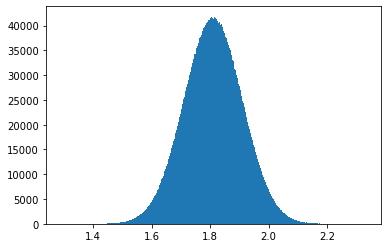

In [10]:
plt.hist(heights, bins=1000);

### Play with the previous steps next 
Note! This is discussed on the lecture video, but basically try experimenting with different number of observations and bins

### Calculating the BMI for every person
Ok, time to really calculate the BMI for everybody. We should have now heights and weights for N persons. And we should understand that indeces for weights and heights arrays are corresponding to the same imaginary person. Let's do the calculations then!


In [11]:
BMIs=weights/heights**2
print(BMIs[1:10])

[27.61109712 24.09676483 17.33512824  7.42220956 20.33355686 25.51665808
 34.08504491 19.6964657  21.05687936]


That's it!

If we would have used basic Java for this, we would have needed to write much more code for this. Now the code is rather readable, don't you think. Knowing the formula, it is easy to follow and understand.

### Drawing couple of histograms for BMIs
Finally, let's make couple of histograms for the BMIs

In [12]:
type(BMIs)

numpy.ndarray

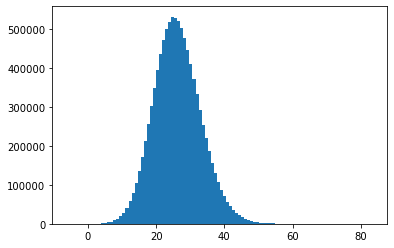

In [13]:
plt.hist(BMIs,100);  # if you take the semicolon out, you will also get some other output, but we don't need it now

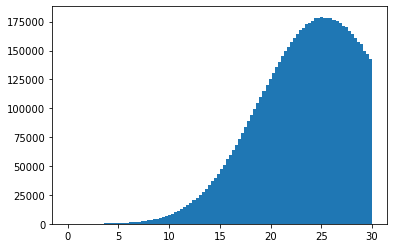

In [14]:
# range option is handy for setting the left and right limits for the image
plt.hist(BMIs,bins=100,range=(0,30));

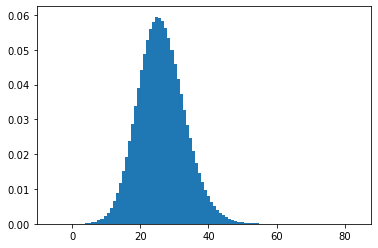

In [15]:
# With the density option the amount under the curve is 1. Hence it starts to give us some idea about the probabilities associated to different BMI values
# This is, however, already beyond the scope of this course...
plt.hist(BMIs,bins=100, density=True);